In [2]:
import os
print(os.getcwd())

/home/malia_pablo


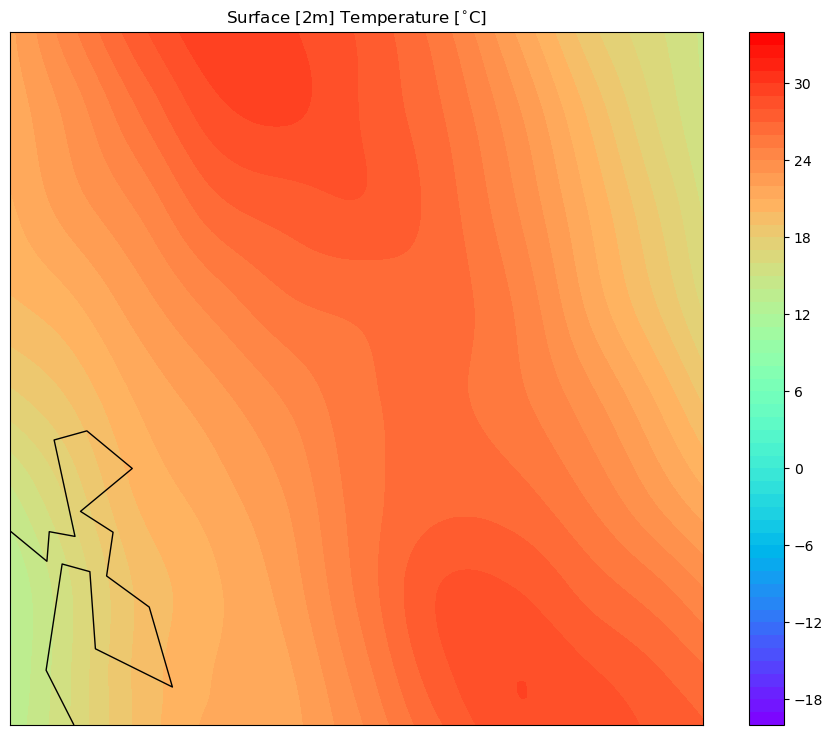

In [7]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap
from wrf import getvar, interplevel, to_np, get_basemap, latlon_coords
import cartopy as cp

# Open the NetCDF file
ncfile = Dataset("wrfout_d01_2020-06-01_00_00_00")
# Extract the pressure
T2 = getvar(ncfile, "T2")
# Get the lat/lon coordinates
lats, lons = latlon_coords(T2)
# Get the basemap object
bm = get_basemap(T2)
# Convert the lat/lon coordinates to x/y coordinates in the projection space
x, y = bm(to_np(lons), to_np(lats))
# Create the figure
fig = plt.figure(figsize=(12,9))
ax = plt.axes()
# Add Coastlines and State Borders from cartopy.feature
# Add the geographic boundaries
bm.drawcoastlines(linewidth=1)
bm.drawstates(linewidth=1)
levels = np.arange(-20,35,1)
p_map = bm.contourf(x, y, to_np(T2)-273, levels=levels, cmap=get_cmap("rainbow"))
plt.colorbar(p_map, ax=ax, orientation="vertical")
plt.title("Surface [2m] Temperature [$^{\circ}$C]")
plt.show()
